<a href="https://colab.research.google.com/github/Aer-3888/EDA_Housing/blob/main/EDA_Immobillier_france_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Housing Prices in Pays de la Loire, France

## Project Overview
This project aims to analyze housing prices in Pays de la Loire, France, with a particular focus on understanding how the COVID-19 pandemic has influenced pricing trends. Through exploratory data analysis (EDA), we will examine key factors affecting housing prices, identify trends over time, and assess any shifts in the market before, during, and after the pandemic.

## Objectives
- Analyze the distribution and trends of housing prices in the region.
- Identify key factors influencing price variations.
- Study the impact of COVID-19 on the housing market by comparing pre-pandemic, pandemic, and post-pandemic data.
- Visualize pricing trends and correlations using statistical and graphical methods.

## Methodology
- Data Cleaning and Preprocessing
- Descriptive Statistics
- Data Visualization (e.g., time series plots, histograms, scatter plots, heatmaps)
- Feature Analysis and Correlation Study
- Comparative Analysis of Pre-COVID, COVID, and Post-COVID Trends

## Data Source
The dataset used for this analysis is sourced from [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2023/#/resources), which provides real estate indicators by municipality and year for the period 2014-2023.

## Tools & Libraries
- Python
- Pandas
- Matplotlib & Seaborn
- NumPy
- Scikit-learn (if applicable for further analysis)


## Data Cleaning and Processing

In [ ]:
# Import tools and libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import dataframe from the dataset
dfs = []
for year in range(2014, 2024):  # Looping from 2014 to 2023
    file_path = f'/content/drive/MyDrive/DataSet/Immobilier_france/Achat/dvf{year}.csv'
    df = pd.read_csv(file_path)
    dfs.append(df)


In [ ]:
# Concatenate all data into one dataframe
data = pd.concat(dfs, axis=0, ignore_index=True)
data.dtypes

,0
Unnamed: 0,int64
INSEE_COM,object
Annee,int64
Nb_mutations,int64
NbMaisons,float64
NbApparts,float64
propmaison,float64
propappart,float64
PrixMoyen,float64
Prixm2Moyen,float64


In [ ]:
data.shape

(290766, 11)

In [ ]:
# Filter data to keep only municipalities from the target region, here Pays de la Loire
# Pays de la loire contains 5 department:
#   44 – Loire-Atlantique
#   49 – Maine-et-Loire
#   53 – Mayenne
#   72 – Sarthe
#   85 – Vendée


department_include = {
    44 : 'Loire-Atlantique',
    49 : 'Maine-et-Loire',
    53 : 'Mayenne',
    72 : 'Sarthe',
    85 : 'Vendée'
}

In [ ]:
# Here we can find out the region thanks to the first 2 number of the insee code of each municipalities
insee_first_2_code = data['INSEE_COM'].str.extract('^(\d{2})')[0] # Extract first 2 number
insee_first_2_code = insee_first_2_code.apply(lambda x : -1 if pd.isna(x) else int(x)) # Convert from string to int
region_filter = (insee_first_2_code.isin(department_include.keys()))
data_region = data[region_filter]
data_region

,Unnamed: 0,INSEE_COM,Annee,Nb_mutations,NbMaisons,NbApparts,propmaison,propappart,PrixMoyen,Prixm2Moyen,SurfaceMoy
13494,13495,44001,2014,14,14.0,0.0,100.000000,0.000000,98821.428571,1404.642857,76.000000
13495,13496,44002,2014,34,34.0,0.0,100.000000,0.000000,204500.000000,2065.617647,101.911765
13496,13497,44003,2014,79,53.0,26.0,67.088608,32.911392,156780.430380,1809.696203,91.721519
13497,13498,44005,2014,61,60.0,1.0,98.360656,1.639344,158866.557377,1856.672131,87.737705
13498,13499,44006,2014,32,32.0,0.0,100.000000,0.000000,172073.437500,2260.687500,79.343750
...,...,...,...,...,...,...,...,...,...,...,...
288950,28196,85302,2023,54,54.0,0.0,100.000000,0.000000,203007.444444,2143.740741,103.333333
288951,28197,85303,2023,24,24.0,0.0,100.000000,0.000000,161741.666667,1568.166667,103.541667
288952,28198,85304,2023,7,7.0,0.0,100.000000,0.000000,168881.142857,1649.285714,107.428571
288953,28199,85305,2023,20,18.0,2.0,90.000000,10.000000,184615.500000,1504.250000,123.750000


In [ ]:
# Map the department name to each municipalities
data_region.loc[:, 'Departement'] = insee_first_2_code.apply(lambda x: department_include[x] if x in department_include else "")

data_region


<ipython-input-7-e7de105aa0c6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_region.loc[:, 'Departement'] = insee_first_2_code.apply(lambda x: department_include[x] if x in department_include else "")


,Unnamed: 0,INSEE_COM,Annee,Nb_mutations,NbMaisons,NbApparts,propmaison,propappart,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,13495,44001,2014,14,14.0,0.0,100.000000,0.000000,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,13496,44002,2014,34,34.0,0.0,100.000000,0.000000,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,13497,44003,2014,79,53.0,26.0,67.088608,32.911392,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,13498,44005,2014,61,60.0,1.0,98.360656,1.639344,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,13499,44006,2014,32,32.0,0.0,100.000000,0.000000,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...,...,...,...,...,...,...
288950,28196,85302,2023,54,54.0,0.0,100.000000,0.000000,203007.444444,2143.740741,103.333333,Vendée
288951,28197,85303,2023,24,24.0,0.0,100.000000,0.000000,161741.666667,1568.166667,103.541667,Vendée
288952,28198,85304,2023,7,7.0,0.0,100.000000,0.000000,168881.142857,1649.285714,107.428571,Vendée
288953,28199,85305,2023,20,18.0,2.0,90.000000,10.000000,184615.500000,1504.250000,123.750000,Vendée


In [ ]:
# Clean the dataframe by retaining the relevant data and removing unnecessary columns

data_region = data_region.drop(columns=['Unnamed: 0', 'Nb_mutations', 'NbMaisons','NbApparts', 'propmaison', 'propappart'])

In [ ]:
data_region

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,44001,2014,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,44002,2014,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,44003,2014,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,44005,2014,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,44006,2014,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...
288950,85302,2023,203007.444444,2143.740741,103.333333,Vendée
288951,85303,2023,161741.666667,1568.166667,103.541667,Vendée
288952,85304,2023,168881.142857,1649.285714,107.428571,Vendée
288953,85305,2023,184615.500000,1504.250000,123.750000,Vendée


In [ ]:
# Split the dataframe into three time periods:
#   - Pre-COVID (2014-2019)
#   - COVID period (2020-2021, as the dataset only contains yearly data)
#   - Post-COVID (2022 and beyond)
# Since the dataset only includes years (not months), we consider COVID to have ended after 2021.
# Note: These periods are based on the region considered, and the starting period may vary in other countries.

df_pre_covid = data_region[data_region['Annee'] <= 2019]
df_covid = data_region[(data_region['Annee'] >= 2020) & (data_region['Annee'] <= 2021)]
df_post_covid = data_region[data_region['Annee'] > 2021]

In [ ]:
df_ventes = data_region.groupby('Annee').size().reset_index(name='Nombre de ventes')

## Data statistics

### **Pre-COVID Housing Market Overview**  
Before COVID-19, the housing market exhibited notable variations in pricing, property size, and sales activity. The average house price across the period was approximately **€134,391**, with a median price of **€127,706**, highlighting a mix of affordability and higher-end transactions. Prices ranged widely, from as low as **€18,000** to as high as **€2,050,000**, reflecting significant disparities between different locations and property types.

The average price per square meter stood at **€1,399**, with a substantial spread from **€333/m² to €8,347/m²**, indicating the influence of both urban and rural housing markets. Similarly, the average home size was **98.9m²**, with most properties falling between **88m² and 107m²**, though some outliers reached **318m²**.

On average, **around 1,197 properties were sold per year** during this period, showing consistent market activity. Market trends showed a gradual increase in prices and property values, suggesting growing demand, especially in later years. This pre-pandemic stability set the stage for potential disruptions and shifts in the housing market once COVID-19 emerged.

In [ ]:
df_pre_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,7180.000000,7.180000e+03,7180.000000,7180.000000
mean,2016.501671,1.343910e+05,1399.220033,98.866031
std,1.713778,5.482981e+04,531.749879,19.277750
min,2014.000000,1.800000e+04,333.000000,25.000000
25%,2015.000000,1.010810e+05,1066.766667,88.333333
50%,2016.000000,1.277064e+05,1295.422222,97.820938
75%,2018.000000,1.589210e+05,1609.635417,107.765224
max,2019.000000,2.050000e+06,8347.500000,318.000000


In [ ]:
df_pre_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2014,1195
1,2015,1205
2,2016,1213
3,2017,1162
4,2018,1180
5,2019,1225


In [ ]:
for year in range(2014,2020):
    display(df_pre_covid[df_pre_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,44001,2014,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,44002,2014,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,44003,2014,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,44005,2014,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,44006,2014,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...
25918,85302,2014,124328.232558,1293.883721,103.651163,Vendée
25919,85303,2014,99220.000000,1034.000000,101.266667,Vendée
25920,85304,2014,133400.000000,1321.181818,103.545455,Vendée
25921,85305,2014,99272.727273,1038.090909,95.000000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
41481,44001,2015,102142.857143,1291.928571,84.785714,Loire-Atlantique
41482,44002,2015,186730.310345,1763.103448,108.931034,Loire-Atlantique
41483,44003,2015,190387.446429,1912.071429,100.839286,Loire-Atlantique
41484,44005,2015,169447.131148,1858.442623,93.016393,Loire-Atlantique
41485,44006,2015,158105.714286,1836.190476,87.761905,Loire-Atlantique
...,...,...,...,...,...,...
54116,85302,2015,115448.717949,1280.461538,90.820513,Vendée
54117,85303,2015,125095.312500,990.312500,130.250000,Vendée
54118,85304,2015,97212.500000,1238.375000,88.000000,Vendée
54119,85305,2015,146496.250000,1146.000000,129.166667,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
69761,44001,2016,136979.411765,1668.058824,95.529412,Loire-Atlantique
69762,44002,2016,176145.588235,1858.294118,95.117647,Loire-Atlantique
69763,44003,2016,143341.521739,1688.228261,87.565217,Loire-Atlantique
69764,44005,2016,167761.538462,1906.046154,91.092308,Loire-Atlantique
69765,44006,2016,182004.000000,1916.966667,96.566667,Loire-Atlantique
...,...,...,...,...,...,...
82503,85302,2016,131787.500000,1352.516667,96.800000,Vendée
82504,85303,2016,121802.631579,1221.842105,103.526316,Vendée
82505,85304,2016,114750.000000,1194.000000,97.000000,Vendée
82506,85305,2016,92745.416667,1006.750000,88.583333,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
97181,44001,2017,118000.000000,1482.500000,79.750000,Loire-Atlantique
97182,44002,2017,187727.272727,2078.000000,90.681818,Loire-Atlantique
97183,44003,2017,195112.428571,1906.836735,104.591837,Loire-Atlantique
97184,44005,2017,190298.033898,1912.711864,103.745763,Loire-Atlantique
97185,44006,2017,157610.809524,2068.428571,80.904762,Loire-Atlantique
...,...,...,...,...,...,...
109315,85302,2017,129370.200000,1402.320000,93.800000,Vendée
109316,85303,2017,98118.181818,1108.545455,84.636364,Vendée
109317,85304,2017,134857.142857,1150.142857,113.000000,Vendée
109318,85305,2017,101275.000000,978.083333,111.333333,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
124046,44001,2018,136964.285714,1467.214286,94.214286,Loire-Atlantique
124047,44002,2018,182112.185185,1899.407407,103.296296,Loire-Atlantique
124048,44003,2018,170861.111111,1989.166667,84.944444,Loire-Atlantique
124049,44005,2018,196174.000000,2145.015625,94.890625,Loire-Atlantique
124050,44006,2018,197418.823529,2125.823529,102.294118,Loire-Atlantique
...,...,...,...,...,...,...
136364,85302,2018,141155.172414,1438.310345,103.241379,Vendée
136365,85303,2018,129986.666667,1156.600000,113.866667,Vendée
136366,85304,2018,109053.750000,1175.750000,96.125000,Vendée
136367,85305,2018,117550.000000,1256.250000,96.375000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
152731,44001,2019,139237.500000,1400.812500,106.375000,Loire-Atlantique
152732,44002,2019,198823.809524,2308.523810,91.309524,Loire-Atlantique
152733,44003,2019,206312.500000,2170.764706,97.029412,Loire-Atlantique
152734,44005,2019,188435.403846,1990.692308,97.259615,Loire-Atlantique
152735,44006,2019,180677.235294,2345.205882,82.176471,Loire-Atlantique
...,...,...,...,...,...,...
166438,85302,2019,156963.275862,1558.068966,103.241379,Vendée
166439,85303,2019,130971.363636,1147.727273,118.500000,Vendée
166440,85304,2019,119370.000000,1393.600000,90.900000,Vendée
166441,85305,2019,133989.421053,1175.052632,114.157895,Vendée


### **COVID-19 Period Housing Market Overview**  
During the COVID-19 period, the housing market experienced fluctuations in pricing, property sizes, and transaction volumes. The average house price increased to approximately **€156,345**, with a median price of **€145,706**, suggesting an upward shift in home values. Prices ranged from **€17,500** to **€464,605**, reflecting a broad spectrum of property values.  

The average price per square meter rose to **€1,590**, compared to the pre-COVID period, with values spanning from **€331/m² to €6,047/m²**. This indicates a continued divergence between different regional markets. The average property size slightly increased to **101.4m²**, with most homes between **92.3m² and 109.2m²**, while some reached **245m²**.  

Sales volumes remained stable during this period, with an **average of approximately 1,225 transactions per year**.

Despite the challenges brought by the pandemic, the housing market demonstrated resilience, with rising prices and relatively steady sales activity. However, regional disparities and shifts in buyer preferences may have contributed to changes in property demand and pricing structures.  

In [ ]:
df_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,2450.000000,2450.000000,2450.000000,2450.000000
mean,2020.500000,156344.542263,1590.365567,101.428317
std,0.500102,60168.972756,658.233467,16.298605
min,2020.000000,17500.000000,331.000000,44.000000
25%,2020.000000,114779.058442,1144.281250,92.301677
50%,2020.500000,145705.971223,1425.455882,100.569048
75%,2021.000000,186919.054545,1870.449975,109.226793
max,2021.000000,464605.224000,6047.564978,245.000000


In [ ]:
min_year_covid = df_covid['Annee'].min()
max_year_covid = df_covid['Annee'].max()
for year in range(min_year_covid, max_year_covid+1):
    display(df_covid[df_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
183049,44001,2020,138911.750000,1569.375000,92.968750,Loire-Atlantique
183050,44002,2020,221262.954545,2374.272727,96.500000,Loire-Atlantique
183051,44003,2020,238587.878788,2246.787879,106.606061,Loire-Atlantique
183052,44005,2020,216318.361446,2147.096386,102.939759,Loire-Atlantique
183053,44006,2020,214479.142857,2575.000000,89.119048,Loire-Atlantique
...,...,...,...,...,...,...
196906,85302,2020,153452.883721,1619.930233,94.162791,Vendée
196907,85303,2020,123072.727273,1209.000000,109.227273,Vendée
196908,85304,2020,141951.105263,1364.894737,114.157895,Vendée
196909,85305,2020,115585.555556,1181.111111,99.370370,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
213882,44001,2021,155694.444444,1718.592593,98.703704,Loire-Atlantique
213883,44002,2021,259295.000000,2664.900000,97.875000,Loire-Atlantique
213884,44003,2021,217944.852941,2656.705882,85.470588,Loire-Atlantique
213885,44005,2021,226662.689655,2374.810345,98.870690,Loire-Atlantique
213886,44006,2021,228055.238095,2602.500000,91.214286,Loire-Atlantique
...,...,...,...,...,...,...
227973,85302,2021,167448.479452,1763.178082,95.589041,Vendée
227974,85303,2021,155182.361111,1572.083333,103.638889,Vendée
227975,85304,2021,141357.894737,1541.105263,101.526316,Vendée
227976,85305,2021,146198.095238,1361.095238,110.952381,Vendée


In [ ]:
df_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2020,1225
1,2021,1225


### **Post-COVID Housing Market Overview**  
Following the COVID-19 period, the housing market continued to evolve, with notable shifts in pricing, property sizes, and sales activity.  

The **average house price** in this period increased compared to pre-COVID levels, with 2022 reaching **€206,280**, followed by some price corrections in 2023. The **median price per square meter** rose to approximately **€2,092/m²** in 2022 before adjusting slightly in 2023. This trend indicates continued high demand but also potential market stabilization.  

The **average home size** in 2022 was **103.1m²**, showing a slight increase from the COVID period, though variations exist across regions.  

**Sales volumes remained stable**, averaging **1,220 transactions per year**.

While prices fluctuated between 2022 and 2023, the market showed resilience, with continued demand despite potential economic uncertainties. The housing sector remains dynamic, influenced by factors such as urban migration, inflation, and shifting buyer preferences.  

In [ ]:
df_post_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,2441.000000,2441.000000,2441.000000,2441.000000
mean,2022.498976,176900.780660,1843.063972,98.955269
std,0.500101,69631.367830,777.778232,16.220966
min,2022.000000,20000.000000,407.000000,25.000000
25%,2022.000000,127750.000000,1318.500000,90.100000
50%,2022.000000,165294.111111,1653.666667,98.391304
75%,2023.000000,214129.268293,2190.174603,106.837838
max,2023.000000,620632.597561,7041.390244,240.000000


In [ ]:
min_year_covid = df_post_covid['Annee'].min()
max_year_covid = df_post_covid['Annee'].max()
for year in range(min_year_covid, max_year_covid+1):
    display(df_post_covid[df_post_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
244871,44001,2022,206280.000000,2092.400000,103.080000,Loire-Atlantique
244872,44002,2022,235138.722222,2467.944444,97.083333,Loire-Atlantique
244873,44003,2022,285050.416667,2886.736111,102.888889,Loire-Atlantique
244874,44005,2022,234155.695652,2734.239130,84.728261,Loire-Atlantique
244875,44006,2022,229074.000000,2884.222222,85.305556,Loire-Atlantique
...,...,...,...,...,...,...
258883,85302,2022,183284.345455,1971.581818,93.818182,Vendée
258884,85303,2022,150018.709677,1388.129032,116.935484,Vendée
258885,85304,2022,170851.500000,1529.714286,112.500000,Vendée
258886,85305,2022,179596.750000,1697.950000,107.950000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
275370,44001,2023,163575.772727,1754.318182,97.409091,Loire-Atlantique
275371,44002,2023,280826.048780,2811.219512,101.536585,Loire-Atlantique
275372,44003,2023,248271.152542,2647.406780,95.779661,Loire-Atlantique
275373,44005,2023,246491.915254,2636.152542,92.949153,Loire-Atlantique
275374,44006,2023,271260.526316,2853.710526,94.842105,Loire-Atlantique
...,...,...,...,...,...,...
288950,85302,2023,203007.444444,2143.740741,103.333333,Vendée
288951,85303,2023,161741.666667,1568.166667,103.541667,Vendée
288952,85304,2023,168881.142857,1649.285714,107.428571,Vendée
288953,85305,2023,184615.500000,1504.250000,123.750000,Vendée


In [ ]:
df_post_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2022,1223
1,2023,1218


### **Overall Housing Market Overview (2014-2023)**  

Over the past decade, the housing market has undergone significant changes in pricing, property sizes, and sales activity.  

- **Average house price:** €147,443  
- **Median house price:** €137,242  
- **Price range:** €17,500 to €2,050,000, showcasing a broad spectrum of affordability and luxury properties.  

The **price per square meter** averaged **€1,528/m²**, with values ranging from **€331/m² to €8,347/m²**, reflecting differences between urban and rural areas.  

The **average home size** was **99.4m²**, with most properties falling between **89.7m² and 107.9m²**, though outliers reached **318m²**.  

#### **Sales Activity**  
The number of **property transactions remained relatively stable**, with annual sales averaging around **1,200 to 1,250 per year**.  
Market trends suggest a gradual **increase in property values over time**, with notable accelerations post-2019 before stabilizing post-COVID.

In [ ]:
data_region.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,12071.000000,1.207100e+04,12071.000000,12071.000000
mean,2018.525971,1.474432e+05,1527.770245,99.404133
std,2.875598,6.160939e+04,639.617352,18.143149
min,2014.000000,1.750000e+04,331.000000,25.000000
25%,2016.000000,1.073917e+05,1119.766667,89.666667
50%,2019.000000,1.372417e+05,1381.500000,98.538462
75%,2021.000000,1.750832e+05,1767.912879,107.857143
max,2023.000000,2.050000e+06,8347.500000,318.000000


In [ ]:
# Seaborn set style
sns.set_theme(style="whitegrid")

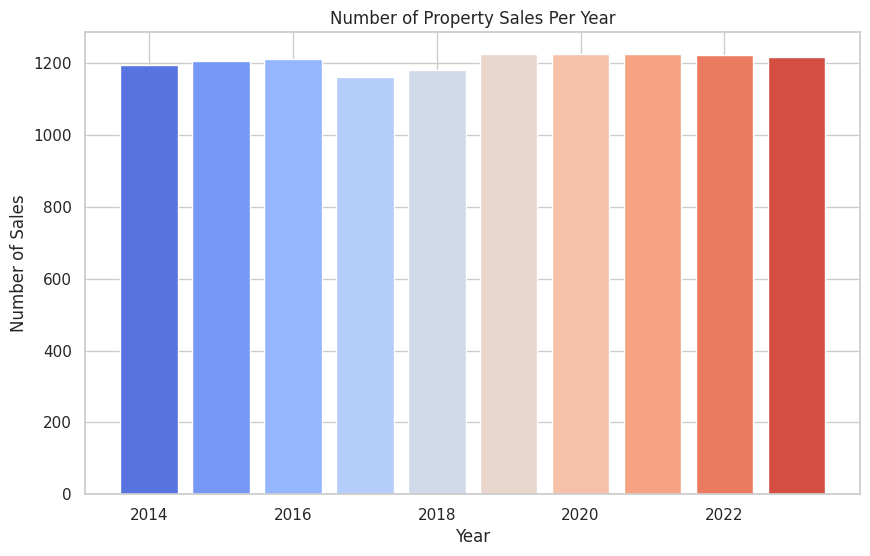

In [ ]:
# Figure 1: Number of Sales Per Year

colors = sns.color_palette("coolwarm", len(df_ventes))
plt.figure(figsize=(10, 6))
bars = plt.bar(df_ventes["Annee"], df_ventes["Nombre de ventes"], color=colors)
plt.xlabel("Year")
plt.ylabel("Number of Sales")
plt.title("Number of Property Sales Per Year")
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=df_ventes["Annee"].min(), vmax=df_ventes["Annee"].max()))
plt.show()

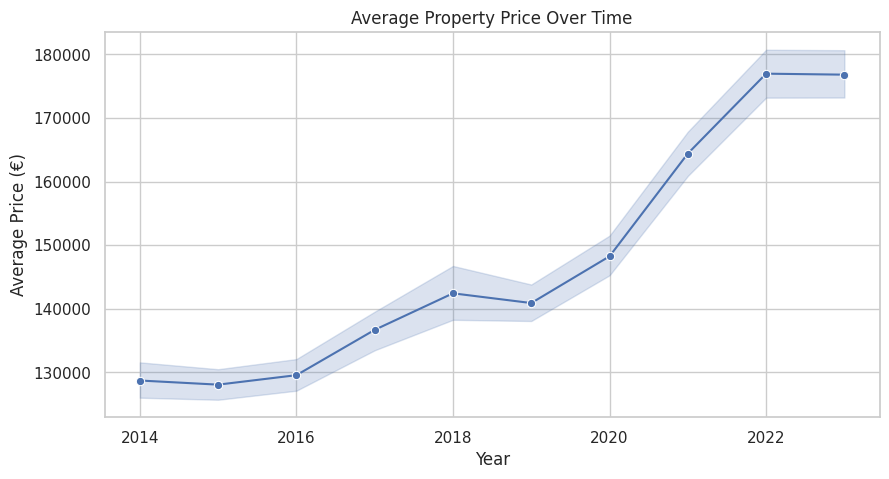

In [ ]:
# Figure 2: Average Price Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(x='Annee', y='PrixMoyen', data=data_region, marker='o', color='b')
plt.xlabel("Year")
plt.ylabel("Average Price (€)")
plt.title("Average Property Price Over Time")
plt.grid(True)
plt.show()

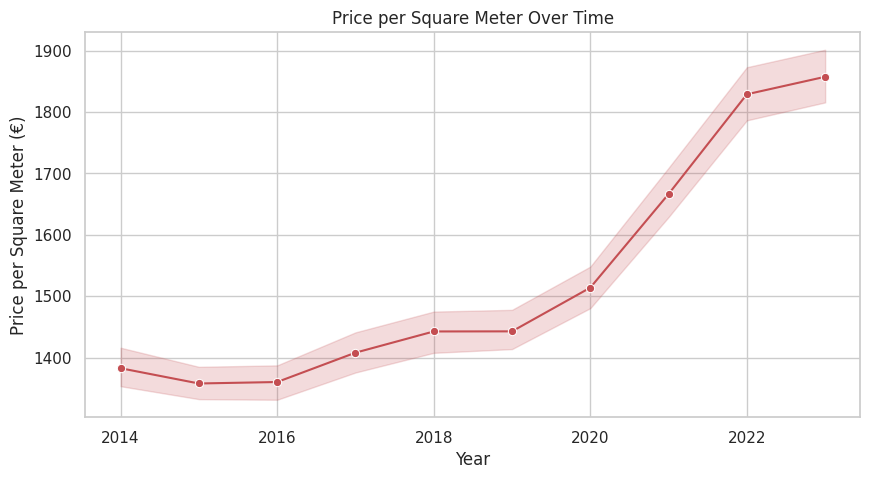

In [ ]:
# Figure 3: Price per Square Meter Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(x='Annee', y='Prixm2Moyen', data=data_region, marker='o', color='r')
plt.xlabel("Year")
plt.ylabel("Price per Square Meter (€)")
plt.title("Price per Square Meter Over Time")
plt.grid(True)
plt.show()

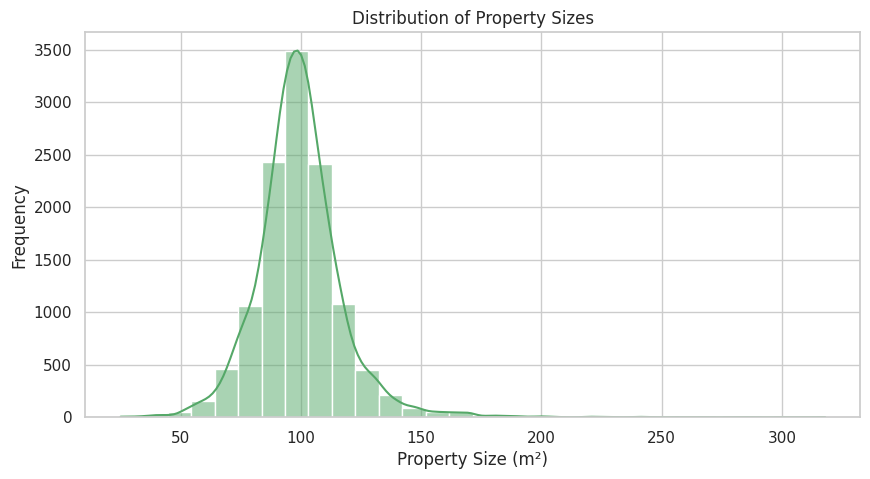

In [ ]:
# Figure 4: Distribution of Property Sizes
plt.figure(figsize=(10, 5))
sns.histplot(data_region['SurfaceMoy'], bins=30, kde=True, color='g')
plt.xlabel("Property Size (m²)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Sizes")
plt.show()

<ipython-input-34-f7a939ff3544>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Annee', y='PrixMoyen', data=data_region, palette='coolwarm')


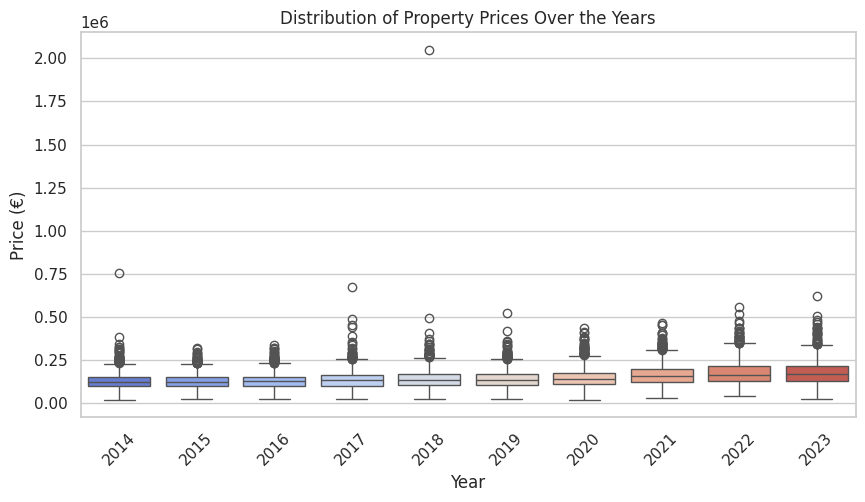

In [ ]:
# Figure 5: Boxplot of Prices Over the Years
plt.figure(figsize=(10, 5))
sns.boxplot(x='Annee', y='PrixMoyen', data=data_region, palette='coolwarm')
plt.xlabel("Year")
plt.ylabel("Price (€)")
plt.title("Distribution of Property Prices Over the Years")
plt.xticks(rotation=45)
plt.show()